In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [115]:
df = pd.read_csv("retail_sales_dataset.csv")

In [116]:
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [117]:
df.shape

(1000, 9)

In [118]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [119]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [120]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [121]:
df.dtypes


Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

In [122]:
df['Date'] = pd.to_datetime(df['Date'])

In [123]:
df.dtypes


Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [124]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [125]:
df.duplicated().sum()

np.int64(0)

In [126]:
df=df.drop_duplicates()

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 90.4 KB


In [128]:
numeric_columns = df.select_dtypes(include=np.number)
statistics = pd.DataFrame({
    'Mean': numeric_columns.mean(),
    'Median' : numeric_columns.median(),
    'Mode': numeric_columns.mode().iloc[0],
    'Standard Deviation':numeric_columns.std()
})
statistics

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


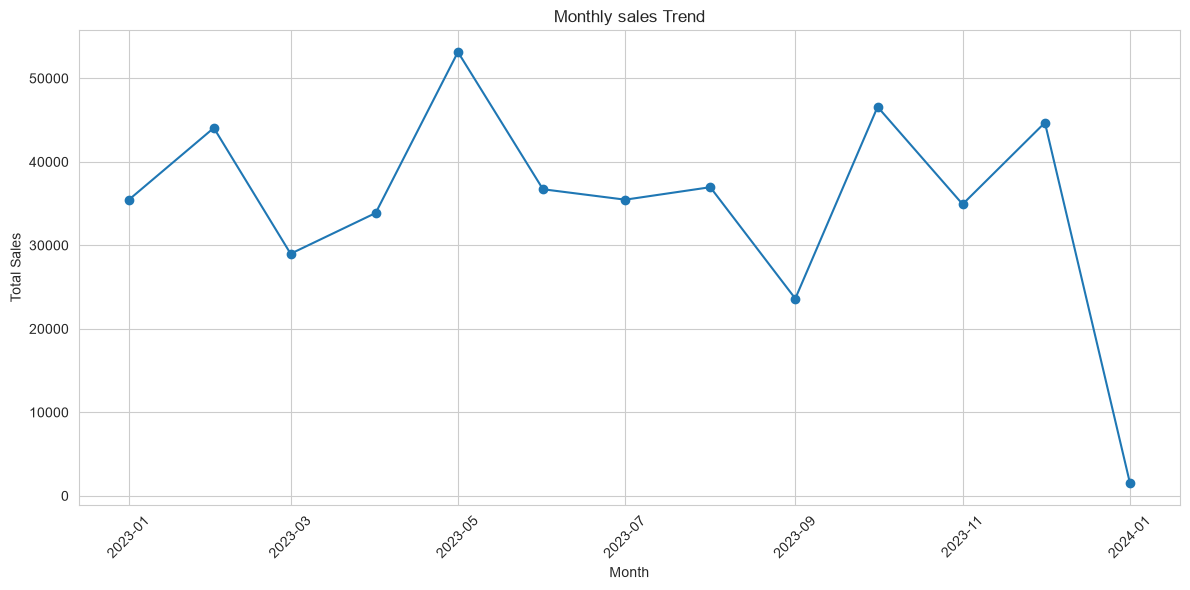

Highest Sales Month:
2023-05-01 00:00:00 53150

Lowest Sales Month:
2024-01-01 00:00:00 1530


In [129]:
df['Month']=df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum()
monthly_sales.index=monthly_sales.index.to_timestamp()
plt.figure(figsize=(12,6))
plt.plot(
monthly_sales.index,
monthly_sales.values,
marker='o'
)
plt.title('Monthly sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Highest Sales Month:")
print(monthly_sales.idxmax(),monthly_sales.max())
print("\nLowest Sales Month:")
print(monthly_sales.idxmin(),monthly_sales.min())



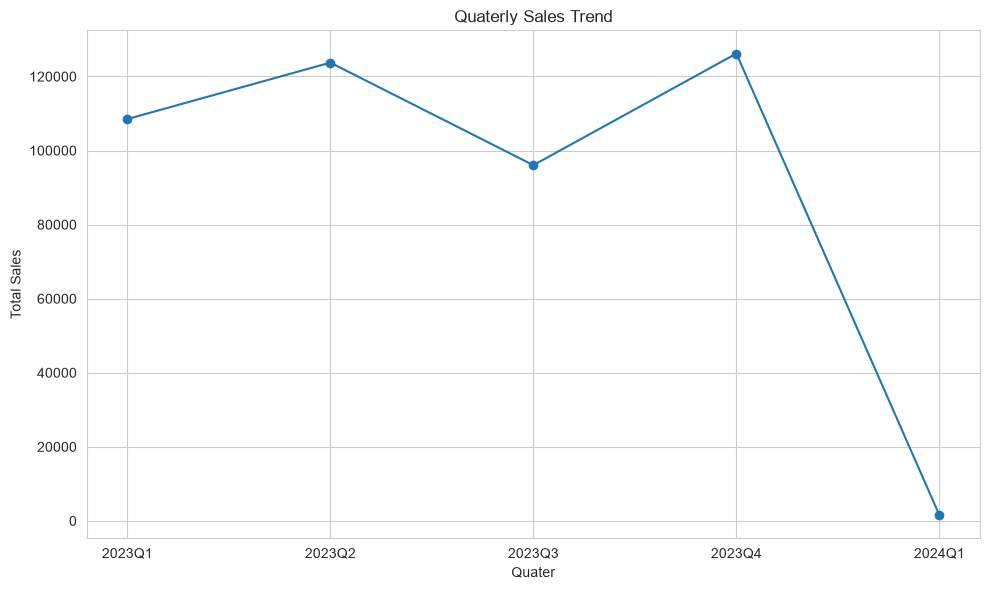

Highest Sales Quater:
2023Q4 126190

Lowest Sales Quater:
2024Q1 1530


In [130]:
df['Quater'] = df['Date'].dt.to_period('Q')

quaterly_sales = df.groupby('Quater')['Total Amount'].sum()

plt.figure(figsize=(10,6))

plt.plot(
    quaterly_sales.index.astype(str),
    quaterly_sales.values,
    marker='o'
)

plt.title('Quaterly Sales Trend')
plt.xlabel('Quater')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

print("Highest Sales Quater:")
print(quaterly_sales.idxmax(),quaterly_sales.max())
print("\nLowest Sales Quater:")
print(quaterly_sales.idxmin(),quaterly_sales.min())


In [131]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]

labels = [
    'Under 18',
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65',
    '65+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)




Age Group
Under 18     21
18-25       148
26-35       205
36-45       202
46-55       229
56-65       195
65+           0
Name: count, dtype: int64


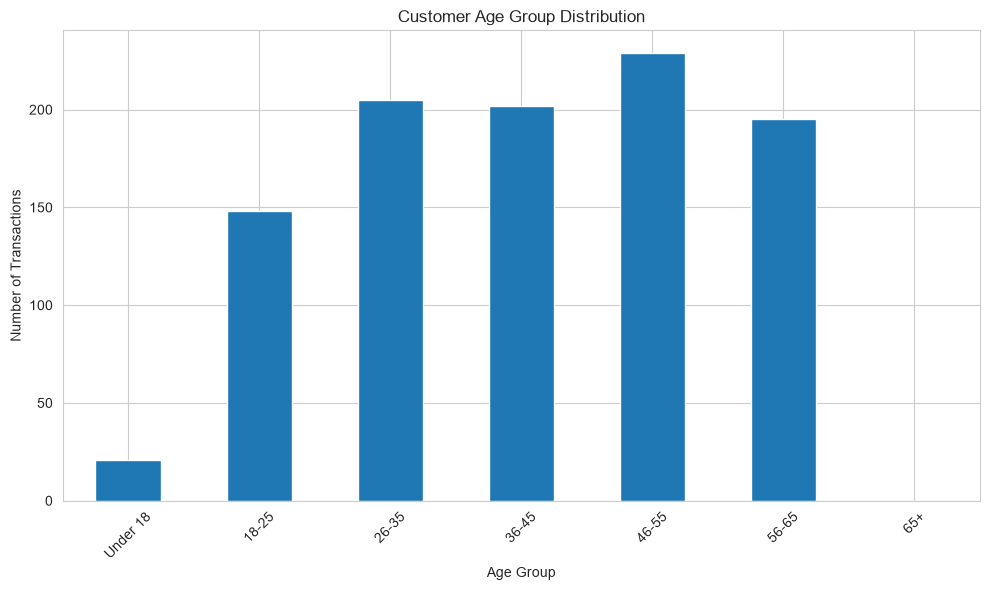

In [132]:
age_groups = df['Age Group'].value_counts().sort_index()

print(age_groups)

plt.figure(figsize=(10,6))

age_groups.plot(kind='bar')

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [133]:
gender_counts = df['Gender'].value_counts()

print(gender_counts)

Gender
Female    510
Male      490
Name: count, dtype: int64


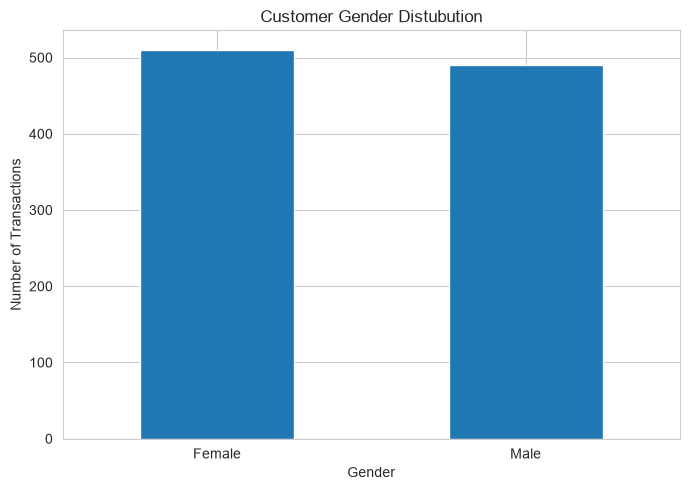

In [134]:
plt.figure(figsize=(7,5))
gender_counts.plot(kind='bar')

plt.title('Customer Gender Distubution')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [135]:
category_quantity =(
    df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
)
print(category_quantity)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


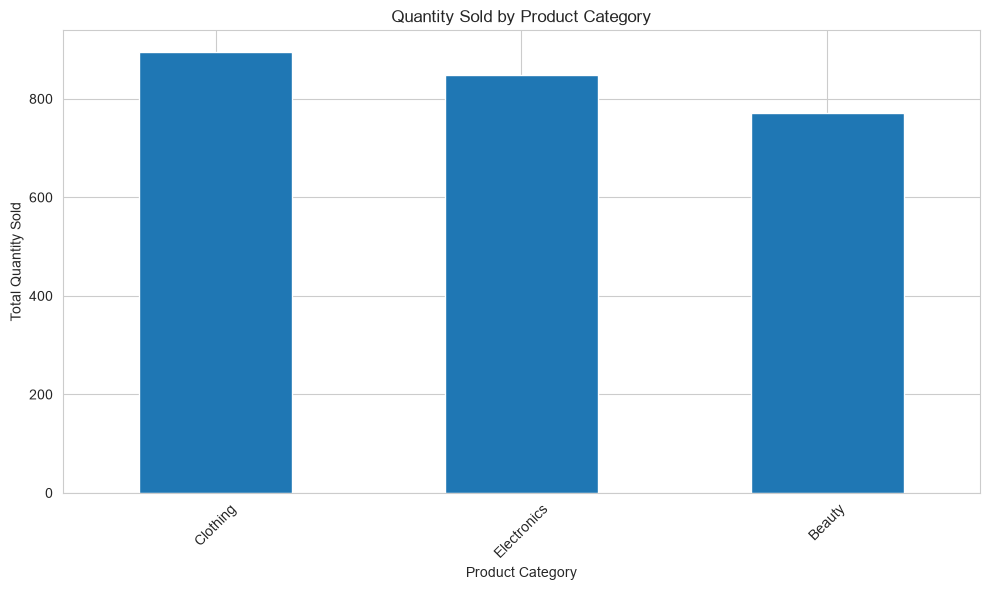

Highest Quantity Category:
Clothing

Lowest Quantity Category:
Beauty


In [136]:
plt.figure(figsize=(10,6))

category_quantity.plot(kind='bar')
plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Highest Quantity Category:")
print(category_quantity.idxmax())
print("\nLowest Quantity Category:")
print(category_quantity.idxmin())

In [137]:
category_revenue=(
    df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
)
print(category_revenue)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


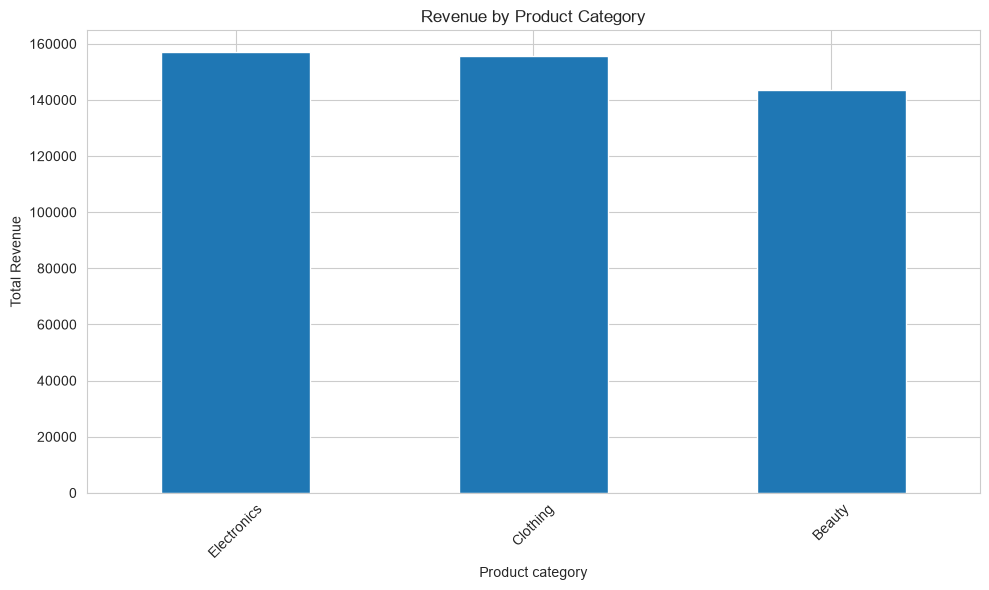

Highest Revenue Category:
Electronics

Lowest Revenue Category:
Beauty


In [138]:
plt.figure(figsize=(10,6))
category_revenue.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.xlabel('Product category')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("Highest Revenue Category:")
print(category_revenue.idxmax())
print("\nLowest Revenue Category:")
print(category_revenue.idxmin())

In [139]:
correlation_data=df[
    ['Age','Quantity','Price per Unit','Total Amount']
    ]
correlation_matrix=correlation_data.corr()
correlation_matrix


,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


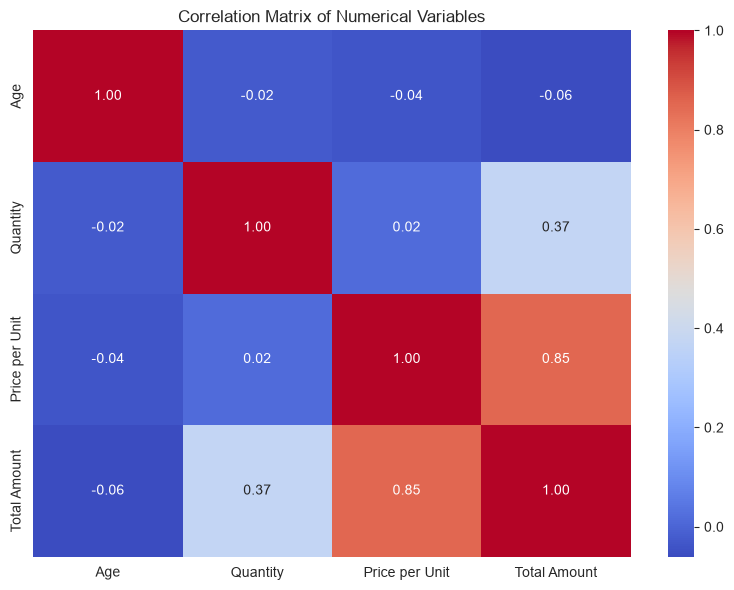

In [140]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()


In [141]:
sales_by_age=(
    df.groupby('Age Group',observed=False)['Total Amount'].sum()
)
print(sales_by_age)

Age Group
Under 18     11215
18-25        73335
26-35        98480
36-45        91870
46-55       100690
56-65        80410
65+              0
Name: Total Amount, dtype: int64


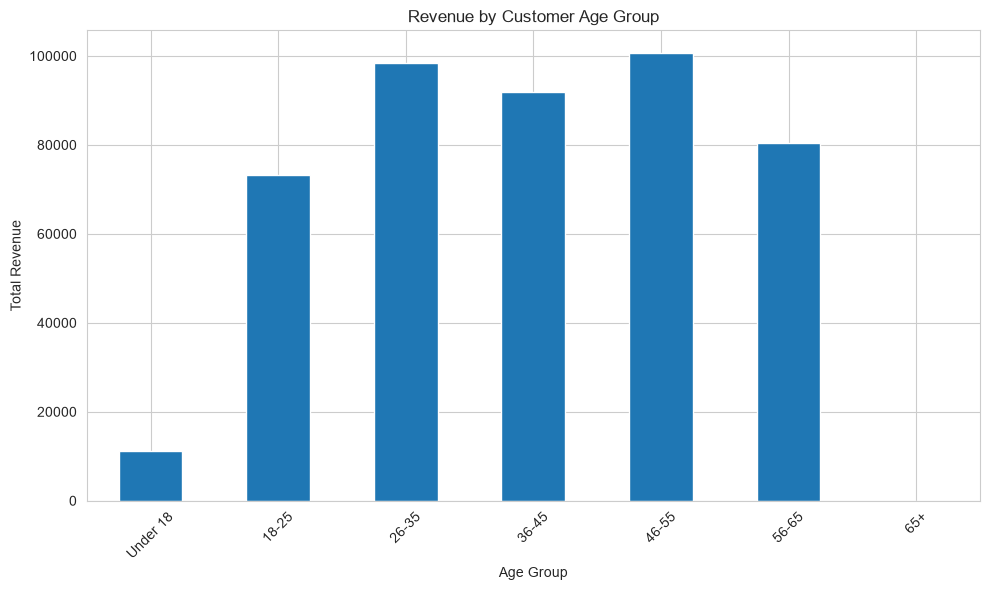

Highest Revenue Age Group:
46-55

Revenue:
100690


In [142]:
plt.figure(figsize=(10,6))
sales_by_age.plot(kind='bar')
plt.title('Revenue by Customer Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Highest Revenue Age Group:")
print(sales_by_age.idxmax())

print("\nRevenue:")
print(sales_by_age.max())

In [143]:
print("Total Revenue:", df['Total Amount'].sum())
print("Average Transaction Value:", df['Total Amount'].mean())
print("Total Quantity Sold:", df['Quantity'].sum())
print("Average Customer Age:", df['Age'].mean())
print("Number of Transactions:", df['Transaction ID'].nunique())
print("Number of Customers:", df['Customer ID'].nunique())

print("\nHighest Revenue Category:")
print(category_revenue.idxmax())

print("\nHighest Quantity Category:")
print(category_quantity.idxmax())

print("\nHighest Revenue Age Group:")
print(sales_by_age.idxmax())

Total Revenue: 456000
Average Transaction Value: 456.0
Total Quantity Sold: 2514
Average Customer Age: 41.392
Number of Transactions: 1000
Number of Customers: 1000

Highest Revenue Category:
Electronics

Highest Quantity Category:
Clothing

Highest Revenue Age Group:
46-55


In [144]:
# Key Findings
#Based on the exploratory data analysis:
#1. The dataset contains 1,000 retail transactions with no missing values or duplicate records.
#2. Monthly and quarterly sales analysis shows variations in revenue over time.
#3. Customer transactions are distributed across different age groups and genders.
#4. Product categories differ in terms of quantity sold and revenue generated.
#5. The correlation analysis provides insights into relationships between age, quantity, price per unit, and total amount.
#6. Revenue by age group helps identify customer segments that contribute more to overall sales.

In [145]:
# Business Recommendations

### 1. Inventory Planning
#The business should maintain sufficient inventory for product categories with high sales volume to reduce the possibility of stock shortages.

### 2. Targeted Marketing
#Marketing campaigns and promotional offers can be designed according to the age groups and customer segments that generate higher revenue.

### 3. Sales Promotions
#The business can introduce special offers and promotional campaigns during lower-performing sales periods to encourage additional purchases.

### 4. Product Strategy
#Revenue and quantity analysis can be used to identify high-performing and lower-performing product categories and support future product planning.

In [146]:
# Conclusion

#The Exploratory Data Analysis of the retail sales dataset provided useful insights into sales trends, customer demographics, product categories, and relationships between numerical variables.

#The analysis of monthly and quarterly sales helped identify changes in sales performance over time. Customer demographic analysis provided an understanding of age-group and gender distributions, while product category analysis showed differences in quantity sold and revenue generated.

#The correlation heatmap and additional age-group revenue analysis provided further insight into customer purchasing behaviour.

#Overall, the findings can help the business improve inventory planning, develop targeted marketing strategies, optimize product decisions, and improve sales performance.